# Interactive Bayesian Optimization (w/UCB Acquisition) for Function 1

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

In [1]:
import numpy as np
#import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm, rankdata
import os

In [2]:
# Load and check initial data
# Initial INPUT file path
X_init = np.load(r"initial_data\function_1\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_1\initial_outputs.npy")

# INPUT file storing historical inputs 2D array (n, dim)
input_file = r"initial_data\function_1\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_1\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 21 points:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.02641195 0.96230658]
 [0.90909091 0.7979798 ]
 [0.83838384 0.6969697 ]
 [0.99262478 0.99870368]
 [0.97790281 0.98695241]
 [0.96010804 0.99091109]
 [0.94648343 0.99476531]
 [0.79558073 0.76375728]
 [0.74414339 0.79937262]
 [0.75885044 0.74021339]
 [0.717171   0.727272  ]]
Historical OUTPUT contains 21 points:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.84327725e-312  9.00749335e-076
  1.32801657e-034  2.43867062e-188 -5.39642424e-176 -1.23657877e-168
 -3.51769270e-164  9.52990859e-033 -4.08768939e-031 -7.98511454e-022
  7.44801241e-013]


In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 2
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 2000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Conduct a grid research if the optimal output has not improved over several queries and exploration is insufficient.
- Alternate between UCB and EI if exploration seems insufficient.

In [4]:
# Grid density for grid search
grid_density = 100
use_grid_search = True    # 'True' or 'False'
# Acquisition type for grid search
acquisition_type = 'ucb'    # 'ucb' or 'ei'

In [5]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # Ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = np.load(r"initial_data\function_1\initial_inputs.npy")
        y = np.load(r"initial_data\function_1\initial_outputs.npy")
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # Avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, trust_region, beta):
    # 20260428, add white noise
    #kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 100.0)) \
    #         + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    # 20260619, change to Matern kernel
    #kernel = Matern(nu = 1.5, length_scale = 1.0, length_scale_bounds = (1e-3, 100.0)) \
    #        + WhiteKernel(noise_level = 1e-1, noise_level_bounds = (1e-6, 10))
    # 20260622, change to Constant kernel
    kernel = ConstantKernel(constant_value = 1.0, constant_value_bounds = (1e-2, 100.0)) * Matern(nu = 1.5, length_scale = 0.2, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-4, 1.0))                                                                                                                                                                         
    model = GaussianProcessRegressor(kernel = kernel, alpha = 1e-5, normalize_y = True, n_restarts_optimizer = 30)
    model.fit(X, y)
    # Generate candidate points
    #candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    candidates = samples_in_trust_region(trust_region, n_candidates)

    # Exclude points that have already been evaluated
    from sklearn.neighbors import NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors = 1, algorithm = 'auto').fit(X)
    distances, _ = neighbors.kneighbors(candidates)
    mask = distances.flatten() > 1e-6
    candidates = candidates[mask]

    print("Use Upper Confidence Bound (UCB) acquisition function within Trust Region.")
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimisation Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Define a function to check whether the optimal output has been unimproved over several queries.
- Define a grid research function to find the point that maximizes the acquisition function.
- Increase `length_scale` of the kernel function to try to improve the fitness of model.

In [6]:
# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    # 20260428, add white noise
    #kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
    #         + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    # 20260630, change to Constant kernel due to ConvergenceWarning
    kernel = ConstantKernel(constant_value = 1.0, constant_value_bounds = (1e-2, 100.0)) * Matern(nu = 1.5, length_scale = 0.2, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-8, 1.0))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 1e-5, normalize_y = True, n_restarts_optimizer = 30)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

**Apr. 22<sup>th</sup>** (before 3<sup>rd</sup> submission)

- Define a function to perform rank transformation on the outputs.

In [7]:
# Define a function to preprocess the data
def preprocess_rank(y):
    ranks = rankdata(y, method = 'average')
    return (ranks - 1) / (len(y) - 1)

def preprocess_log(y):
    y_transformed = np.zeros_like(y, dtype=np.float64)
    mask_neg = y < 0
    y_transformed[mask_neg] = np.log(np.abs(y[mask_neg]) + 1e-300) - 700.0
    mask_pos = ~mask_neg
    y_transformed[mask_pos] = np.log(y[mask_pos] + 1e-300)
    return y_transformed

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement the Trust Region approach. <br>Based on the current optimal output point, define a hypercube Trust Region. If the optimal outputs improve continuously, expand the radius; if no improvement, reduce the radius.

In [8]:
trust_region_file = r"initial_data\function_1\trust_region.npy"

def load_trust_region(X, y, filename = trust_region_file):
    if os.path.exists(filename):
        region = np.load(filename, allow_pickle = True).item()
        best_so_far = X[np.argmax(y)]
        if not np.array_equal(region['center'], best_so_far):
            region['center'] = best_so_far.copy()
        return region
    else:
        center = X[np.argmax(y)]
        print("Create initial Trust Region.")
        return {
            'center': center.copy(),
            'radius': 0.1,
            'bounds': bounds,
            'improvement_counter': 0,
            'unimprovement_counter': 0
        }

def save_trust_region(region, filename = trust_region_file):
    region_to_save = {
        'center': region['center'],
        'radius': region['radius'],
        'bounds': region['bounds'],
        'improvement_counter': region['improvement_counter'],
        'unimprovement_counter': region['unimprovement_counter']
    }
    np.save(filename, region_to_save, allow_pickle=True)
    print("Trust Region file is updated.")


def update_trust_region(region, new_center, improved = False):
    region['center'] = new_center.copy()
    if improved:
        region['improvement_counter'] += 1
        region['unimprovement_counter'] = 0
        if region['improvement_counter'] >= 2:
            region['radius'] = max(region['radius'] * 0.8, 0.05)
            print(f"Trust Region shrunk to radius {region['radius']:.4f}")
            region['improvement_counter'] = 0
    else:
        region['unimprovement_counter'] += 1
        region['improvement_counter'] = 0
        if region['unimprovement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.5, 0.5)
            print(f"Trust Region expanded to radius {region['radius']:.4f}")
            region['unimprovement_counter'] = 0
    save_trust_region(region)

def samples_in_trust_region(region, n_points):
    n_local = int(n_points * 0.2)
    n_global = n_points - n_local
    lower = np.maximum(region['center'] - region['radius'], region['bounds'][:, 0])
    upper = np.minimum(region['center'] + region['radius'], region['bounds'][:, 1])
    lower = np.clip(lower, region['bounds'][:, 0], region['bounds'][:, 1])
    upper = np.clip(upper, region['bounds'][:, 0], region['bounds'][:, 1])
    local_samples = np.random.uniform(lower, upper, size = (n_local, dim))
    global_samples = np.random.uniform(region['bounds'][:, 0], region['bounds'][:,1], size = (n_global, dim))
    return np.vstack([local_samples, global_samples])

Load historical data
Loaded 21 points. And the historical OUTPUT:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.84327725e-312  9.00749335e-076
  1.32801657e-034  2.43867062e-188 -5.39642424e-176 -1.23657877e-168
 -3.51769270e-164  9.52990859e-033 -4.08768939e-031 -7.98511454e-022
  7.44801241e-013]
Current best output: 0.0000000000


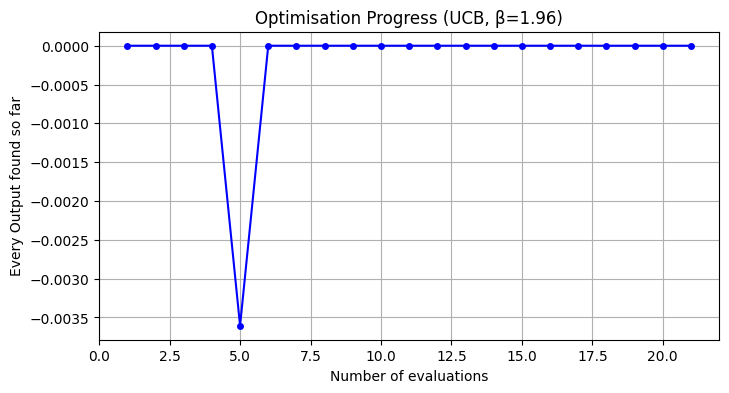

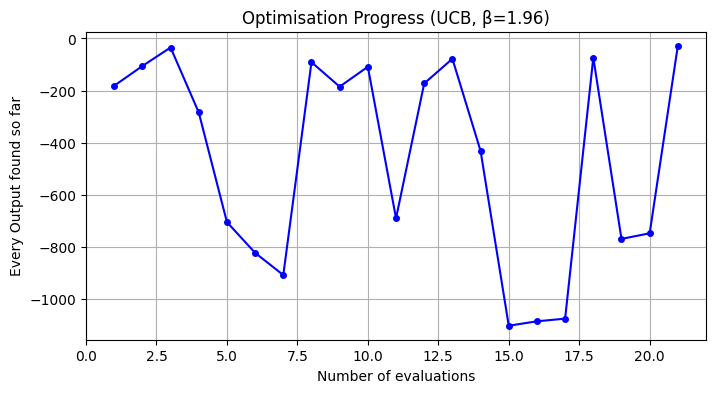

In [9]:
# 3. Load historical data and view current status
X, y = load_data()
# Implement rank transformation
#y_rank = preprocess_rank(y)
# Implement log transformation
y_log = preprocess_log(y)

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    previous_best = np.max(y)
    print(f"Current best output: {previous_best:.10f}")
    plot_progress(X, y, beta)
    #plot_progress(X, y_rank, beta)
    plot_progress(X, y_log, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [10]:
# 4. Recommend the next point to submit

#trust_region = load_trust_region(X, y_rank)
trust_region = load_trust_region(X, y_log)
print(f"Trust region center: {trust_region['center']}, radius: {trust_region['radius']:.4f}")

if use_grid_search:
    print("Output has been unimproved over several queries. Use grid research for exploration.")
    #x_next, best_acquisition_value = grid_search_acquisition(X, y_rank, bounds, grid_density, acquisition_type)
    x_next, best_acquisition_value = grid_search_acquisition(X, y_log, bounds, grid_density, acquisition_type)
    print(f"Grid search selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    #x_next, best_acquisition_value = suggest_next_point(X, y_rank, trust_region, beta)
    x_next, best_acquisition_value = suggest_next_point(X, y_log, trust_region, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Trust region center: [0.717171 0.727272], radius: 0.3375
Output has been unimproved over several queries. Use grid research for exploration.
Use Upper Confidence Bound (UCB) acquisition function.
Predicted mean = -210.234446, std = 301.988468, UCB = 381.662951
Grid search selected point with acquisition value: 381.662951
The 12th recommended input point:
[0.717171 0.747474]
0.717171-0.747474


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")

print(f"There are {len(X)} points, and current best output: {np.max(y):.10f}")

plot_progress(X, y, beta)

# Update Trust Region
if np.max(y) > previous_best:
    improved = True
    print("Trust Region updated.")
else:
    improved = False
    print("Trust Region is not updated.")
best_X = X[np.argmax(y)]
update_trust_region(trust_region, best_X, improved)